In [5]:
using DifferentialEquations, Flux, Optim, DiffEqFlux, DiffEqSensitivity, Plots


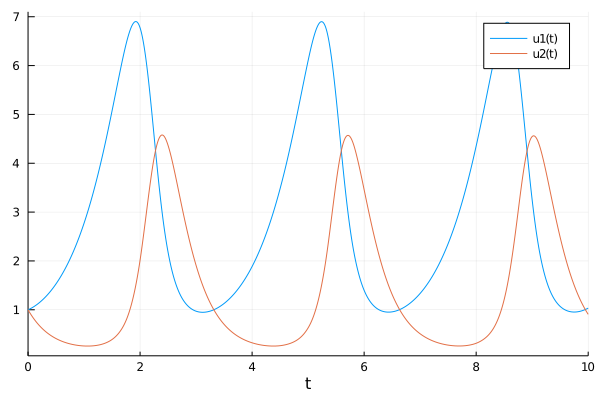

In [6]:
function lotka_volterra!(du, u, p, t)
    x, y = u
    α, β, δ, γ = p
    du[1] = dx = α*x - β*x*y
    du[2] = dy = -δ*y + γ*x*y
  end
  
  # Initial condition
  u0 = [1.0, 1.0]
  
  # Simulation interval and intermediary points
  tspan = (0.0, 10.0)
  tsteps = 0.0:0.1:10.0
  
  # LV equation parameter. p = [α, β, δ, γ]
  p = [1.5, 1.0, 3.0, 1.0]
  
  # Setup the ODE problem, then solve
  prob = ODEProblem(lotka_volterra!, u0, tspan, p)
  sol = solve(prob, Tsit5())
  
  # Plot the solution
  using Plots
  plot(sol)

In [13]:
  function loss(p)
    sol = solve(prob, Tsit5(), p=p, saveat = tsteps)
    loss = sum(abs2, sol.-1)
    return loss, sol
  end
  
  callback = function (p, l, pred)
    display(l)
    plt = plot(pred, ylim = (0, 6))
    display(plt)
    # Tell sciml_train to not halt the optimization. If return true, then
    # optimization stops.
    return false
  end
  
  result_ode = Flux.train!(loss, p, ADAM(0.1), cb = callback)

LoadError: MethodError: no method matching train!(::typeof(loss), ::Vector{Float64}, ::ADAM; cb=var"#13#14"())
[0mClosest candidates are:
[0m  train!(::Any, ::Any, ::Any, [91m::Any[39m; cb) at /Users/chentianchi/.julia/packages/Flux/sY3yx/src/optimise/train.jl:97

In [11]:
using Flux